In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
dataset = pd.read_csv("../assets/csv-files/churn-modelling.csv")
dataset.head(3)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


In [10]:
# Drop columns with object (string) type data
dataset = dataset.select_dtypes(exclude=["object"])
dataset.head(3)

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,619,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,608,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,502,42,8,159660.80,3,1,0,113931.57,1


In [11]:
# Check for null values
dataset.isnull().sum() # No null values

RowNumber          0
CustomerId         0
CreditScore        0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [12]:
# Seperate input and output data
input_data = dataset.iloc[:, :-1]
output_data = dataset.iloc[:, -1]

In [13]:
# Scaling the input data
from sklearn.preprocessing import StandardScaler

In [14]:
ss = StandardScaler()
input_data = pd.DataFrame(ss.fit_transform(input_data), columns=input_data.columns)

In [15]:
# Train test split
from sklearn.model_selection import train_test_split

In [16]:
x_train, x_test, y_train, y_test = train_test_split(input_data, output_data, test_size=0.2, random_state=42)

In [17]:
# Create an artificial neural network
import tensorflow
from keras.layers import Dense
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from keras.regularizers import L2

In [18]:
ann = Sequential() # Object initialization

In [19]:
# Build different layers
ann.add(Dense(8, input_dim=x_train.shape[1], activation="relu",  kernel_regularizer=L2(l2=0.01))) # First hidden layer
ann.add(Dense(6, activation="relu", kernel_regularizer=L2(l2=0.01)))
ann.add(Dense(4, activation="relu", kernel_regularizer=L2(l2=0.01)))  
ann.add(Dense(2, activation="relu", kernel_regularizer=L2(l2=0.01)))  
ann.add(Dense(1, activation="sigmoid")) 


C:\Users\kusha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
# Compile the model
ann.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [21]:
# Train the model
ann.fit(x_train, y_train, batch_size=100, epochs=50, validation_data=(x_test, y_test), callbacks=EarlyStopping())

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7890 - loss: 0.8903 - val_accuracy: 0.8035 - val_loss: 0.8224
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8010 - loss: 0.8039 - val_accuracy: 0.8035 - val_loss: 0.7530
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7932 - loss: 0.7408 - val_accuracy: 0.8035 - val_loss: 0.7006
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7980 - loss: 0.6912 - val_accuracy: 0.8035 - val_loss: 0.6606
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7992 - loss: 0.6536 - val_accuracy: 0.8035 - val_loss: 0.6296
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7926 - loss: 0.6274 - val_accuracy: 0.8035 - val_loss: 0.6056
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7935 - loss: 0.6050 - val_accuracy: 0.8035 - val_loss: 0.5866
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7935 - loss: 0.5876 - val_accuracy: 0.8035 - val_loss:

In [22]:
# Training and testing accuracy of each epoch
train_accuracy = ann.history.history["accuracy"]
test_accuracy = ann.history.history["val_accuracy"]
train_accuracy, test_accuracy

([0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.794499

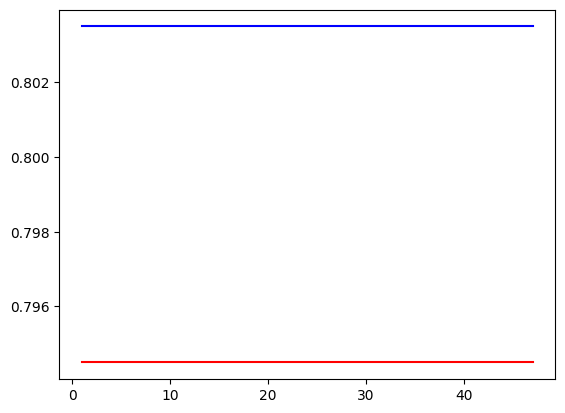

In [23]:
# Visualize the accuracy
plt.plot([i+1 for i in range(len(test_accuracy))], test_accuracy, color="blue")
plt.plot([i+1 for i in range(len(train_accuracy))], train_accuracy, color="red")
plt.show()

In [24]:
# Check the accuracy of our model
from sklearn.metrics import accuracy_score

In [25]:
# Predictions of x_train
predict_x_train = ann.predict(x_train)
x_train_predictions = []
for i in predict_x_train:
    if i[0] > 0.5:
        x_train_predictions.append(1)
    else:
        x_train_predictions.append(0)
# View predictions
x_train_predictions

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 886us/step


[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [26]:
# Predictions of x_test
predict_x_test = ann.predict(x_test)
x_test_predictions = []
for i in predict_x_test:
    if i[0] > 0.5:
        x_test_predictions.append(1)
    else:
        x_test_predictions.append(0)
# View predictions
x_test_predictions

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [27]:
# Get accuracy
train_data_accuracy = accuracy_score(y_train, x_train_predictions) * 100 
test_data_accuracy = accuracy_score(y_test, x_test_predictions) * 100
train_data_accuracy, test_data_accuracy

(79.45, 80.35)

In [28]:
"""If the training accuracy is more than testing accuracy, the model is overfitted.
To avoid overfitting we use Batch Normalization to minimize the gaps between the accuracies."""

'If the training accuracy is more than testing accuracy, the model is overfitted.\nTo avoid overfitting we use Batch Normalization to minimize the gaps between the accuracies.'

#### Batch Normalization

In [29]:
from keras.layers import BatchNormalization

In [30]:
# Build different layers
ann.add(Dense(8, input_dim=x_train.shape[1], activation="relu",  kernel_regularizer=L2(l2=0.01)))
ann.add(BatchNormalization()) # Applying batch normalization on first hidden layer output
ann.add(Dense(6, activation="relu", kernel_regularizer=L2(l2=0.01)))
ann.add(BatchNormalization()) # Applying batch normalization on second hidden layer output
ann.add(Dense(4, activation="relu", kernel_regularizer=L2(l2=0.01)))  
ann.add(BatchNormalization()) # Applying batch normalization on third hidden layer output
ann.add(Dense(2, activation="relu", kernel_regularizer=L2(l2=0.01)))  
ann.add(BatchNormalization()) # Applying batch normalization on fourth hidden layer output
ann.add(Dense(1, activation="sigmoid")) 
# Batch normalization is not required in output layer


C:\Users\kusha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
# Compile the model
ann.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [32]:
# Train the model
ann.fit(x_train, y_train, batch_size=100, epochs=50, validation_data=(x_test, y_test), callbacks=EarlyStopping())

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7912 - loss: 0.8129 - val_accuracy: 0.8035 - val_loss: 0.7449
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7967 - loss: 0.7027 - val_accuracy: 0.8035 - val_loss: 0.6464
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7928 - loss: 0.6282 - val_accuracy: 0.8035 - val_loss: 0.5973
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7944 - loss: 0.5790 - val_accuracy: 0.8035 - val_loss: 0.6360


In [33]:
# Training and testing accuracy of each epoch
train_accuracy = ann.history.history["accuracy"]
test_accuracy = ann.history.history["val_accuracy"]
train_accuracy, test_accuracy

([0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798],
 [0.8034999966621399,
  0.8034999966621399,
  0.8034999966621399,
  0.8034999966621399])

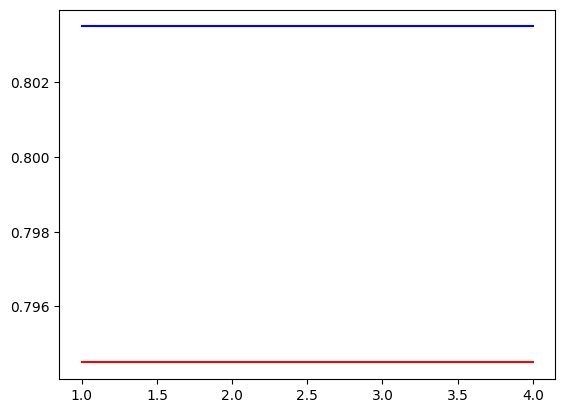

In [34]:
# Visualize the accuracy
plt.plot([i+1 for i in range(len(test_accuracy))], test_accuracy, color="blue")
plt.plot([i+1 for i in range(len(train_accuracy))], train_accuracy, color="red")
plt.show()